# ETF Arbitrage Demo (Standalone Engine + yfinance)

This notebook is an **interview-ready**, fully runnable demo:
- Downloads price data with **yfinance** (and caches locally).
- Implements a small but complete **backtest engine** (positions, cash, PnL, trade log, costs).
- Runs ETF arbitrage idea:

  * **Improved**: z-score entry/exit, dollar-neutral sizing, risk controls.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from datetime import date
import warnings


warnings.filterwarnings('ignore')

class TradingEngine:
    def __init__(self, initial_capital=100000.0, commission_bps=0.0001):
        self.cash = initial_capital
        self.initial_capital = initial_capital
        self.commission_bps = commission_bps
        self.positions = {} # {ticker: {'qty': 0, 'avg_price': 0.0}}
        self.history = []
        self.equity_curve = [] # Track daily portfolio value

    def get_portfolio_value(self, current_prices):
        """Returns Cash + Market Value of Positions"""
        market_value = 0.0
        for ticker, pos in self.positions.items():
            if ticker in current_prices:
                market_value += pos['qty'] * current_prices[ticker]
        return self.cash + market_value

    def execute_order(self, ticker, qty, price, date, action_label):
        """
        Handles Buy/Sell logic including Cash deduction.
        """
        if qty == 0: 
            return

        # Calculate Cost & Commission
        notional = abs(qty * price)
        comm = notional * self.commission_bps 
        

        self.cash -= (qty * price) 
        self.cash -= comm
        
        # Update Position State
        current_pos = self.positions.get(ticker, {'qty': 0, 'avg_price': 0.0})
        curr_qty = current_pos['qty']
        
        # Check direction
        is_same_direction = (curr_qty * qty) > 0 or curr_qty == 0
        
        if is_same_direction:
            # scale in 
            new_total_qty = curr_qty + qty
            old_notional = curr_qty * current_pos['avg_price']
            new_trade_notional = qty * price
        
            new_avg_price = price
            if new_total_qty != 0:
                new_avg_price = (old_notional + new_trade_notional) / new_total_qty
            
            self.positions[ticker] = {'qty': new_total_qty, 'avg_price': new_avg_price}
            
        else:
        
            # update quantity 
            new_total_qty = curr_qty + qty
            if new_total_qty == 0:
                if ticker in self.positions: del self.positions[ticker]
            else:
                is_flip = (curr_qty * new_total_qty) < 0
                new_avg_price = price if is_flip else current_pos['avg_price']
                self.positions[ticker] = {'qty': new_total_qty, 'avg_price': new_avg_price}

        # log trade
        self.history.append({
            'date': date, 'ticker': ticker, 'action': action_label,
            'qty': qty, 'price': price, 'comm': comm
        })
        
def portfolio_analytics(equity: pd.Series, periods_per_year=252):
    equity = equity.dropna()
    rets = equity.pct_change().dropna()

    # Sharpe (rf=0)
    sharpe = np.nan
    if rets.std() != 0:
        sharpe = (rets.mean() / rets.std()) * np.sqrt(periods_per_year)

    # Drawdown
    peak = equity.cummax()
    dd = equity / peak - 1.0
    max_dd = dd.min()

    # Max DD duration (in days)
    underwater = equity < peak
    dd_duration = (underwater.groupby((underwater != underwater.shift()).cumsum())
                            .cumcount() + 1)
    max_dd_duration = dd_duration[underwater].max() if underwater.any() else 0

    # CAGR
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    if years > 0:
        cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1/years) - 1 
    else:
        cagr = np.nan

    # Vol (annualized)
    ann_vol = rets.std() * np.sqrt(periods_per_year)

    return {
        "Final Equity": float(equity.iloc[-1]),
        "Total Return": float(equity.iloc[-1] / equity.iloc[0] - 1),
        "CAGR": float(cagr),
        "Ann Vol": float(ann_vol),
        "Sharpe (rf=0)": float(sharpe),
        "Max Drawdown": float(max_dd),
        "Max DD Duration (days)": int(max_dd_duration),
    }, dd, rets

        
# get data 
def get_aligned_market_data():
    """
    Fetches target etf and its underlying components 
    """
    tickers = ['XOM', 'CVX', 'EOG', 'SLB', 'COP']
    etf_ticker = 'XLE' 
    
    print(f"Downloading data for {len(tickers)} stocks + {etf_ticker}")
    
    # Download 
    raw_df = yf.download(tickers + [etf_ticker], start="2005-01-01", end=date.today(), progress=False)
    
    data = raw_df['Close'].dropna() # type: ignore
    
    data.rename(columns={etf_ticker: 'ETF_PROXY'}, inplace=True) # type: ignore
    
    print(f"Simulation Range: {data.index.min().date()} to {data.index.max().date()}")
    print(f"Total Trading Days: {len(data)}")
    return data



In [2]:
## strategy improvement using z score to get a statistical score of divergence instead of an absolute deviation. 

def run_z_score_backtest(data, engine, window=120, entry_z=2.0, exit_z=0.5):

    # data
    rets = np.log(data / data.shift(1))
    etf_col = 'ETF_PROXY'
    components = [c for c in rets.columns if c != etf_col]
    
    basket_ret = rets[components].mean(axis=1) ## equal weighted synthetic
    print("basket rets:", basket_ret)
    etf_ret = rets[etf_col]
    
    # Rolling Beta & Z-Score
    rolling_cov = etf_ret.rolling(window).cov(basket_ret)
    rolling_var = basket_ret.rolling(window).var()
    rolling_var = rolling_var.replace(0, np.nan)
    rolling_beta = rolling_cov / rolling_var
    
    spread_ret = etf_ret - (rolling_beta * basket_ret)
    z_score = (spread_ret - spread_ret.rolling(window).mean()) / spread_ret.rolling(window).std()

    print(spread_ret.describe())

    print("Check Spread - Plot")
    plt.figure(figsize=(8,6))
    plt.plot(data.index, spread_ret, label = "spread check", linewidth = 1.5)
    plt.show()

    print("Check Spread Stationarity:")
    adf = adfuller(spread_ret.dropna())
    print("ADF stat:", adf[0], "p:", adf[1])

    # param
    capital_per_trade = 60000.0
    
    # run
    print(f"Strategy started with Cash: ${engine.cash:,.2f}")
    
    dates = data.index
    for i in range(window, len(dates)):
        today = dates[i]
        yesterday = dates[i-1] 
        
        # 1. Get Signal
        z_val = z_score.loc[yesterday]
        beta_val = rolling_beta.loc[yesterday]
        
        if np.isnan(z_val) or np.isnan(beta_val): continue
            
        today_prices = data.loc[today]
        current_pos_qty = engine.positions.get(etf_col, {}).get('qty', 0)
        
        # Trading Logic 
        
        # ENTRY: Long Spread
        if z_val < -entry_z and current_pos_qty <= 0:
            if current_pos_qty < 0:
                engine.execute_order(etf_col, -current_pos_qty, today_prices[etf_col], today, "CLOSE_SHORT")
                for t in components:
                    p_qty = engine.positions.get(t, {}).get('qty', 0)
                    if p_qty != 0: engine.execute_order(t, -p_qty, today_prices[t], today, "CLOSE_HEDGE")
            
            qty_etf = capital_per_trade / today_prices[etf_col]
            engine.execute_order(etf_col, qty_etf, today_prices[etf_col], today, "BUY_ETF")
            
            beta_used = 0.9 * beta_val + 0.1 * 1.0
            hedge_amt = capital_per_trade * beta_used
            qty_per_stock = -1 * (hedge_amt / len(components))
            for t in components:
                engine.execute_order(t, qty_per_stock / today_prices[t], today_prices[t], today, "SELL_BASKET")

        # ENTRY: Short Spread
        elif z_val > entry_z and current_pos_qty >= 0:
            if current_pos_qty > 0:
                engine.execute_order(etf_col, -current_pos_qty, today_prices[etf_col], today, "CLOSE_LONG")
                for t in components:
                    p_qty = engine.positions.get(t, {}).get('qty', 0)
                    if p_qty != 0: engine.execute_order(t, -p_qty, today_prices[t], today, "CLOSE_HEDGE")
            
            qty_etf = -1 * (capital_per_trade / today_prices[etf_col])
            engine.execute_order(etf_col, qty_etf, today_prices[etf_col], today, "SELL_ETF")
            
            beta_used = 0.9 * beta_val + 0.1 * 1.0
            hedge_amt = capital_per_trade * beta_used
            qty_per_stock = (hedge_amt / len(components))
            for t in components:
                engine.execute_order(t, qty_per_stock / today_prices[t], today_prices[t], today, "BUY_BASKET")

        # EXIT: Mean Reversion
        elif abs(z_val) < exit_z and current_pos_qty != 0:
            engine.execute_order(etf_col, -current_pos_qty, today_prices[etf_col], today, "EXIT_ETF")
            for t in components:
                p_qty = engine.positions.get(t, {}).get('qty', 0)
                if p_qty != 0: engine.execute_order(t, -p_qty, today_prices[t], today, "EXIT_HEDGE")
        
        # Mark-to-Market
        engine.equity_curve.append({'date': today, 'equity': engine.get_portfolio_value(today_prices)})

    return pd.DataFrame(engine.equity_curve).set_index('date')




Simulation Range: 2005-01-03 to 2026-02-20
Total Trading Days: 5317
Ticker            COP        CVX        EOG        SLB  ETF_PROXY        XOM
Date                                                                        
2005-01-03  15.956021  22.669788  11.425583  20.659575   9.636076  24.711365
2005-01-04  15.851685  22.513905  11.245316  20.502008   9.586493  24.543634
2005-01-05  15.969302  22.660875  11.150893  20.566324   9.545174  24.415367
2005-01-06  16.200747  23.039446  11.315705  20.968260   9.710458  24.726173
2005-01-07  16.098301  22.781136  11.241879  20.428057   9.633323  24.563372
basket rets: Date
2005-01-03         NaN
2005-01-04   -0.008766
2005-01-05    0.000672
2005-01-06    0.015527
2005-01-07   -0.011374
                ...   
2026-02-13    0.004399
2026-02-17   -0.013263
2026-02-18    0.025486
2026-02-19    0.005705
2026-02-20   -0.011755
Length: 5317, dtype: float64
count    5197.000000
mean        0.000005
std         0.003949
min        -0.029473
25%      

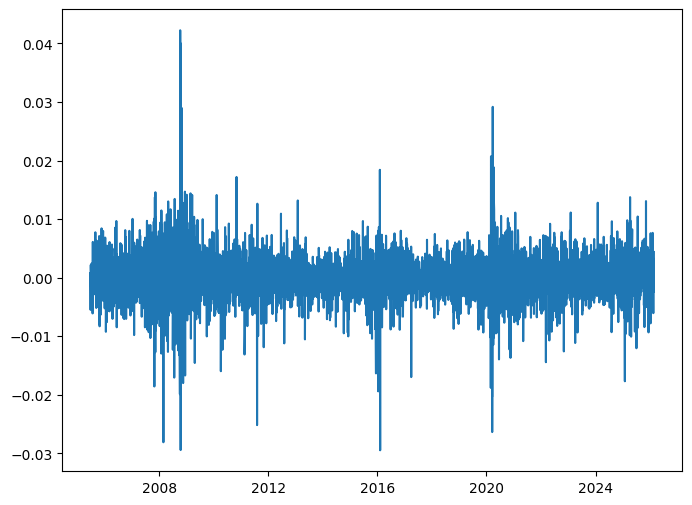

Check Spread Stationarity:
ADF stat: -19.23659640417061 p: 0.0
Strategy started with Cash: $100,000.00
Final Cash Balance: $114,765.35
Final PnL: $14,765.35


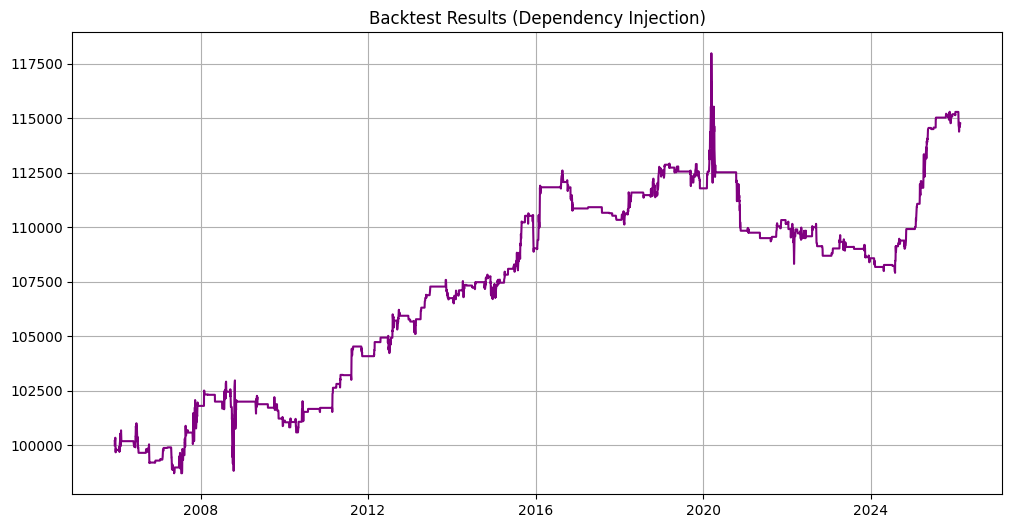

Final Equity              114765.354996
Total Return                   0.147654
CAGR                           0.006846
Ann Vol                        0.020975
Sharpe (rf=0)                  0.336449
Max Drawdown                  -0.085369
Max DD Duration (days)      1492.000000
dtype: float64


<Axes: title={'center': 'Drawdown'}, xlabel='date'>

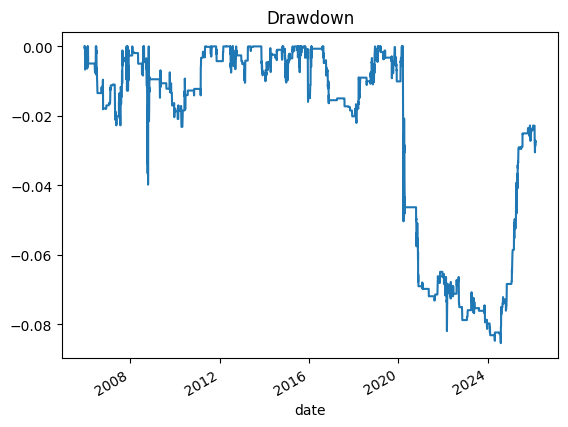

In [3]:

df = get_aligned_market_data()
print(df.head())
dates = df.index 

engine = TradingEngine(initial_capital= 100000, commission_bps=0)

equity_df = run_z_score_backtest(df, engine, window=120, entry_z=2.0, exit_z=0.2)


# Results
print(f"Final Cash Balance: ${engine.cash:,.2f}")
print(f"Final PnL: ${(engine.equity_curve[-1]['equity'] - 100000):,.2f}")
plt.figure(figsize=(12, 6))
plt.plot(equity_df['equity'], label='Portfolio Value', color='purple')
plt.title('Backtest Results (Dependency Injection)')
plt.grid(True)
plt.show()

stats, dd, rets = portfolio_analytics(equity_df["equity"])
print(pd.Series(stats))

dd.plot(title="Drawdown")


## Volatility Harvesting 

With reference to _Fernholz, E. R., & Karatzas, I. (2008, January 10). Stochastic Portfolio Theory: An overview_, Fernholz defines excess growth of a self-financing portfolio to be:
$$ \gamma^\ast_\pi (t) := \frac{1}{2}\Bigl( \sum^n _{i=1} \pi_i(t) a_{ii}(t) - \sum^n _{i=1}\sum^n _{j=1}\pi_i(t)\pi_j(t)a_{ij}(t) \Bigl) $$


Starting Volatility Harvest on NUGT:
Target: 50.0% | Band: +/- 3.0%
Final Equity              488110.963791
Total Return                   3.918427
CAGR                           0.170342
Ann Vol                        0.461974
Sharpe (rf=0)                  0.573653
Max Drawdown                  -0.659003
Max DD Duration (days)      2286.000000
dtype: float64
Final Equity              265811.853494
Total Return                   1.658119
CAGR                           0.101317
Ann Vol                        0.922650
Sharpe (rf=0)                  0.577555
Max Drawdown                  -0.969120
Max DD Duration (days)      2401.000000
dtype: float64


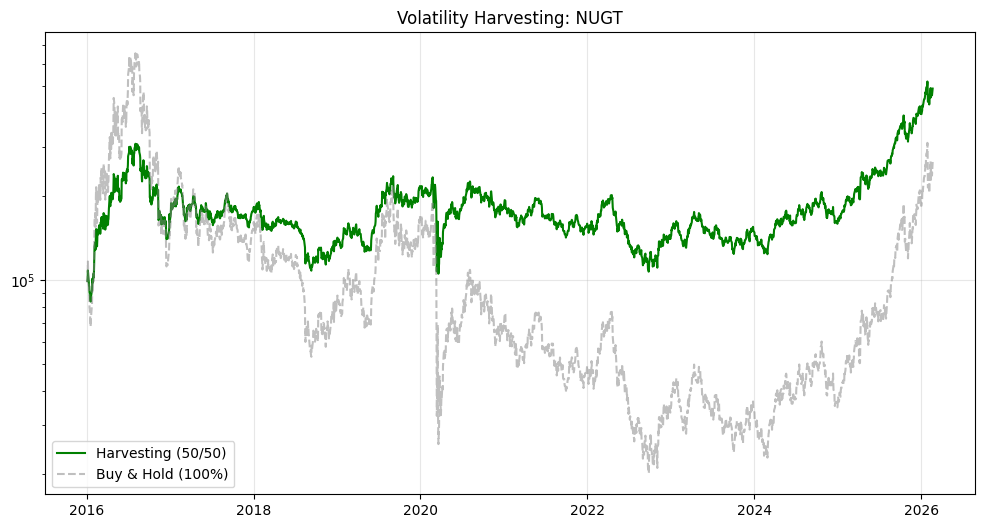

In [4]:
# VOLATILITY HARVESTING 
def run_volatility_harvesting(data, engine, target_weight=0.70, tolerance_band=0.05):
    """
    Strategy: Shannon's Demon / Constant Mix
    """
    ticker = data.columns[0] 
    price_series = data[ticker] 
    dates = data.index
    
    print(f"Starting Volatility Harvest on {ticker}:")
    print(f"Target: {target_weight*100}% | Band: +/- {tolerance_band*100}%")

    # Initial Entry (All-in to Target)
    initial_price = price_series.iloc[0] 
    initial_equity = engine.cash
    
    # check for empty cash
    if initial_equity <= 0: return pd.DataFrame()

    target_val = initial_equity * target_weight
    qty = target_val / initial_price
    
    engine.execute_order(ticker, qty, initial_price, dates[0], "INITIAL_ENTRY")
    
    # Rebalancing Loop
    for i in range(1, len(dates)):
        today = dates[i]
        price = price_series.iloc[i] 
        

        # Note: We need the engine to tell us the current holdings
        current_pos_info = engine.positions.get(ticker, {'qty': 0})
        current_pos_qty = current_pos_info['qty']
        
        stock_val = current_pos_qty * price
        cash_val = engine.cash
        total_equity = stock_val + cash_val
        
        current_weight = 0.0
        if total_equity > 0:
            current_weight = stock_val / total_equity
            
        deviation = current_weight - target_weight
        
        # Rebalance Trigger
        if abs(deviation) > tolerance_band:
            # We need to get back to Target Weight
            target_stock_val = total_equity * target_weight
            diff_dollars = target_stock_val - stock_val # (+Buy / -Sell)
            
            qty_to_trade = diff_dollars / price
            
            action = "REBAL_BUY" if qty_to_trade > 0 else "REBAL_SELL"
            engine.execute_order(ticker, qty_to_trade, price, today, action)
        
        # Log Equity
        post_trade_equity = (engine.positions.get(ticker, {'qty': 0})['qty'] * price) + engine.cash
        engine.equity_curve.append({'date': today, 'equity': post_trade_equity})

    return pd.DataFrame(engine.equity_curve).set_index('date')


# ==========================================
# EXECUTION
# ==========================================

print("Downloading NUGT:")
gol_df = yf.download(['NUGT'], start ="2016-01-01", progress=False)['Close']
gol_df = gol_df.dropna()

if isinstance(gol_df, pd.Series):
    gol_df = gol_df.to_frame()


harvest_engine = TradingEngine(initial_capital=100000, commission_bps=0)
harvest_res = run_volatility_harvesting(gol_df, harvest_engine, target_weight=0.50, tolerance_band=0.03)


final_eq = harvest_engine.cash + (harvest_engine.positions.get('NUGT', {}).get('qty', 0) * gol_df.iloc[-1, 0])

stats_harv, dd_harvs, ret_harv  = portfolio_analytics(harvest_res['equity'])
print(pd.Series(stats_harv))

plt.figure(figsize=(12, 6))
plt.plot(harvest_res['equity'], label='Harvesting (50/50)', color='green')

# Benchmark (Buy & Hold)
initial_price = gol_df.iloc[0, 0]
shares_bh = 100000 / initial_price
benchmark = gol_df['NUGT'] * shares_bh
benchmark_stats, benchmark_dd, benchmark_rets = portfolio_analytics(benchmark)
print(pd.Series(benchmark_stats))

plt.plot(benchmark, label='Buy & Hold (100%)', color='gray', linestyle='--', alpha=0.5)

plt.title('Volatility Harvesting: NUGT')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
def QED(data, target_weight, engine):
    ticker = data.columns[0] 
    price_series = data[ticker] 
    asset_log_rets = np.log(price_series / price_series.shift(1)).dropna()
    sigma2 = asset_log_rets.var() * 252  

    theoretical_egr = 0.5 * target_weight * (1 - target_weight) * sigma2

    print(f"Annualized Variance (Sigma^2): {sigma2:.4f}")
    print(f"Theoretical Excess Growth (Fernholz): {theoretical_egr:.4%}")

    strat_final = engine.equity_curve[-1]['equity']
    strat_start = engine.equity_curve[0]['equity']
    years = len(dates) / 252
    strat_cagr = (strat_final / strat_start) ** (1 / years) - 1

    # 2. Calculate "Drift" Portfolio Growth Rate (Control Group)
    # If we bought 50% TQQQ and 50% Cash on Day 1 and never touched it:
    initial_stock_val = strat_start * 0.50
    initial_cash_val  = strat_start * 0.50
    final_stock_val = initial_stock_val * (price_series.iloc[-1] / price_series.iloc[0])
    drift_final = final_stock_val + initial_cash_val

    drift_cagr = (drift_final / strat_start) ** (1 / years) - 1

    # 3. The Difference is the Excess Growth
    realized_egr = strat_cagr - drift_cagr

    print(f"Strategy CAGR: {strat_cagr:.4%}")
    print(f"Drift (Control) CAGR: {drift_cagr:.4%}")
    print(f"Realized Excess Growth: {realized_egr:.4%}")

In [6]:
QED(gol_df, target_weight=0.5, engine=harvest_engine )

Annualized Variance (Sigma^2): 0.8909
Theoretical Excess Growth (Fernholz): 11.1364%
Strategy CAGR: 7.8423%
Drift (Control) CAGR: 2.9031%
Realized Excess Growth: 4.9392%
